<a href="https://colab.research.google.com/github/3OMDEH/Machine-Learning-Projects-Beginner-/blob/main/Diabetes_Prediction_i.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#@title Reading the Data
import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


In [3]:
file_list = os.listdir(path)
print(file_list)

['diabetes.csv']


# **Data Overview**

In [4]:
#@title Creating the DataFrame
df = pd.read_csv(os.path.join(path, file_list[0]))
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
#@title Checking Missing Values (Nothing were Found)
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
#@title Checking Duplicate Values (Nothing were Found)
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### **Observations from Descriptive Statistics (`df.describe()`)**

Here's what we can observe from the mean, standard deviation, min, max, and quartiles for each column:

*   **Pregnancies:**
    *   `Mean`: Approximately 3.8 pregnancies.
    *   `Min`: 0, `Max`: 17. The range is quite wide, indicating a diverse group of individuals in terms of number of pregnancies.
    *   `Quartiles`: 25% of women had 1 or fewer pregnancies, 50% had 3 or fewer, and 75% had 6 or fewer. The distribution seems right-skewed, with fewer women having a very high number of pregnancies.

*   **Glucose, BloodPressure, SkinThickness, Insulin, BMI:**
    *   **Critical Observation:** For all these columns, the `min` value is 0. This is **biologically unrealistic** for `Glucose` (blood sugar), `BloodPressure`, `BMI` (body mass index), and `Insulin` (unless the patient is undergoing specific medical treatment or has a specific condition). `SkinThickness` can legitimately be 0 if the measurement is not taken or is very low, but often 0 here indicates missing data.
    *   These zero values are likely placeholders for missing data and will need to be handled, as they can significantly skew the mean, standard deviation, and any model built on this data. For instance, a `Glucose` level of 0 is impossible for a living person.
    *   `Glucose`: `Mean` 120.9, `Std` 32.0. The wide standard deviation suggests variability. The non-zero minimum for a healthy individual is much higher than 0.
    *   `BloodPressure`: `Mean` 69.1, `Std` 19.4. Similar to Glucose, a blood pressure of 0 is impossible. The mean is within a healthy range, but the standard deviation indicates a good spread.
    *   `SkinThickness`: `Mean` 20.5, `Std` 16.0. Again, a `min` of 0. This could represent missing data, as a person would generally have some skin thickness.
    *   `Insulin`: `Mean` 79.8, `Std` 115.2. The extremely high standard deviation relative to the mean, combined with a `min` of 0 and a `max` of 846, suggests a very skewed distribution, likely with many zero values and some very high outliers. A value of 0 for insulin is also physiologically problematic.
    *   `BMI`: `Mean` 32.0, `Std` 7.9. A `min` of 0 for BMI is impossible. The mean indicates that on average, the population in this dataset is in the obese category (BMI > 30).

*   **DiabetesPedigreeFunction:**
    *   `Mean`: 0.47, `Std`: 0.33. This function assesses the risk of diabetes based on family history. The range from 0.078 to 2.42 suggests varying degrees of genetic predisposition.

*   **Age:**
    *   `Mean`: 33.2, `Std`: 11.8. The `min` is 21 and `max` is 81, showing a broad age range. The quartiles indicate that 75% of individuals are 41 or younger, suggesting a younger-leaning population in this dataset.

*   **Outcome:**
    *   `Mean`: 0.349. This is essentially the proportion of individuals with diabetes (1) in the dataset, which is about 34.9%. This confirms our earlier observation of class imbalance, where roughly one-third of the individuals have diabetes.
    *   `Min`: 0, `Max`: 1, as expected for a binary outcome.

**In Summary:**

The most significant observation is the presence of 0 values in columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`. These zeros are highly indicative of missing data that have been coded as 0. This is a critical data quality issue that needs to be addressed before any meaningful analysis or model training can be performed. Ignoring these zeros would lead to inaccurate statistics and potentially flawed model predictions.

Outcome Distribution (Counts):
 Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Distribution (Percentages):
 Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


/tmp/ipykernel_14856/1186214506.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


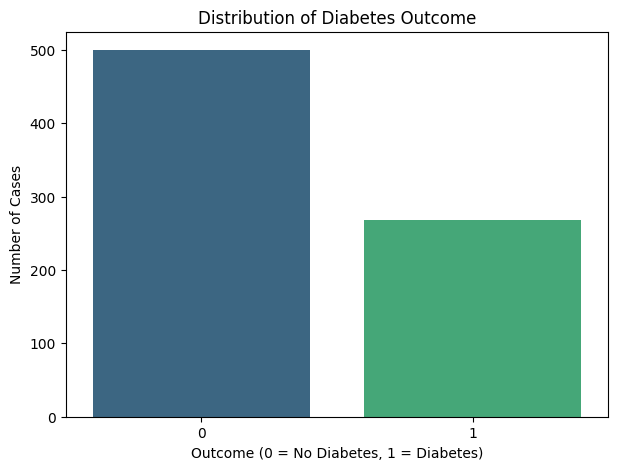

In [9]:
#@title Distribution of 'Outcome' Column
outcome_counts = df['Outcome'].value_counts()
outcome_percentages = df['Outcome'].value_counts(normalize=True) * 100

print("Outcome Distribution (Counts):\n", outcome_counts)
print("\nOutcome Distribution (Percentages):\n", outcome_percentages.round(2))

plt.figure(figsize=(7, 5))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Cases')
plt.show()

The `Outcome` column represents whether a patient has diabetes (1) or not (0).

From the plot and the counts, we can observe that the dataset is imbalanced. There are significantly more individuals without diabetes (Outcome 0) than with diabetes (Outcome 1). This is a common characteristic in medical datasets and might need to be addressed during model training to prevent the model from being biased towards the majority class.

A `countplot` is generally preferred over a pie chart for showing categorical distributions as it makes it easier to compare the magnitudes of different categories.

# **Data Preprocessing**

In [10]:
#@title Splitting into X, Y

x = df.drop(['Outcome'], axis=1)
y = df['Outcome']


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (614, 8)
Shape of x_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


In [11]:
#@title Impute Biologically Wrong Values
columns_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for column in columns_to_impute:
    # Calculate the median of the column, excluding zeros
    median_val = df[df[column] != 0][column].median()
    # Replace zeros with the calculated median
    df[column] = df[column].replace(0, median_val)

print("DataFrame after imputing zero values:")
print(df.head())
print("\nDescriptive statistics after imputation:")
print(df.describe())

DataFrame after imputing zero values:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Descriptive statistics after imputation:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.67187

In [12]:
#@title Standardization
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [13]:
#@title OverSampling
smote = SMOTE(random_state=0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("Shape of x_train_resampled:", x_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)
print("Class distribution of y_train_resampled:\n", pd.Series(y_train_resampled).value_counts())

Shape of x_train_resampled: (786, 8)
Shape of y_train_resampled: (786,)
Class distribution of y_train_resampled:
 Outcome
1    393
0    393
Name: count, dtype: int64


Class distribution of y_train_resampled:
Outcome
1    393
0    393
Name: count, dtype: int64


/tmp/ipykernel_14856/4241682577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=pd.Series(y_train_resampled), palette='viridis')


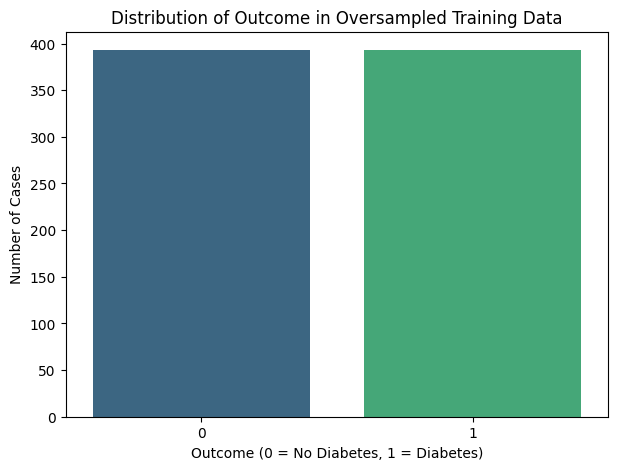

In [14]:
#@title Verify Balanced Data Distribution
print("Class distribution of y_train_resampled:")
print(pd.Series(y_train_resampled).value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x=pd.Series(y_train_resampled), palette='viridis')
plt.title('Distribution of Outcome in Oversampled Training Data')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Cases')
plt.show()

# **KNN Model**

In [32]:
N_neighbors = [1, 3, 5, 7, 9, 11, 13, 15]

best_accuracy = 0
best_N = None

for i in N_neighbors:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train_resampled, y_train_resampled)
    y_pred_current = knn.predict(x_test)
    current_accuracy = accuracy_score(y_test, y_pred_current)

    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_N = i

print(f"Best N_neighbors: {best_N}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Best N_neighbors: 1
Best Accuracy: 0.7662


In [33]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=1)

In [34]:
y_pred = knn.predict(x_test) # Prediction on test set

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7662


In [35]:
conf_matrix = confusion_matrix(y_test, y_pred)
ClassificationReport = classification_report(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", ClassificationReport)

Confusion Matrix:
 [[87 20]
 [16 31]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.81      0.83       107
           1       0.61      0.66      0.63        47

    accuracy                           0.77       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.77      0.77      0.77       154

